# Walmart Store Sales — Prophet v4: event-aware holiday windows

v3 proved that a fixed 50/50 blend of direct Prophet and 52-week seasonal naive is strong. v4 preserves that blend and changes only Prophet's calendar representation.

The old model used one generic `walmart_holiday` label on the flagged week. Here holiday weeks are identified by event type, and events with known pre-holiday demand receive a one-week lead window:

```text
Super Bowl     → event week only
Labor Day      → event week only
Thanksgiving  → one prior week + event week
Christmas     → one prior week + event week
```

The dates and windows are known before forecasting; no sales-derived future feature and no external-covariate imputation is used.

- validation: final `39` train weeks;
- metric: Kaggle-style WMAE, holiday weight `5`;
- scope: all `3,331` Store-Dept series;
- final forecast remains `0.50 × seasonal naive + 0.50 × direct Prophet`.


In [37]:
%pip install -q "prophet>=1.1,<2" "wandb>=0.19,<1" "pandas>=2.2,<3" "numpy>=1.26,<3" "matplotlib>=3.8,<4" "scikit-learn>=1.4,<2"


In [38]:
from __future__ import annotations

import json
import logging
import os
import platform
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wandb
from prophet import Prophet

warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)

pd.set_option("display.max_columns", 120)
print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "wandb": wandb.__version__,
})


{'python': '3.12.13', 'pandas': '2.2.2', 'numpy': '2.0.2', 'wandb': '0.28.0'}


In [39]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as exc:
    print(f"Not running in Colab or Drive unavailable: {exc}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Configuration

`holiday_windows_days` uses Prophet's day units. Weekly Walmart rows are Fridays, so `-7` includes the Friday one week before the event-week row.

In [40]:
SEED = 42
np.random.seed(SEED)

HOLIDAY_WINDOWS_DAYS = {
    "super_bowl": (0, 0),
    "labor_day": (0, 0),
    "thanksgiving": (-7, 0),
    "christmas": (-7, 0),
}

CONFIG = {
    "seed": SEED,
    "validation_weeks": 39,
    "holiday_weight": 5.0,
    "top_n_series": None,
    "min_history_points": 52,
    "seasonal_lag_weeks": 52,
    "prophet_blend_weight": 0.50,
    "holiday_windows_days": HOLIDAY_WINDOWS_DAYS,
    "growth": "linear",
    "yearly_seasonality": True,
    "weekly_seasonality": False,
    "daily_seasonality": False,
    "seasonality_mode": "additive",
    "changepoint_prior_scale": 0.05,
    "seasonality_prior_scale": 10.0,
    "holidays_prior_scale": 10.0,
    "interval_width": 0.80,
    "prediction_clip_min": 0.0,
    "prediction_clip_max": 300000.0,
    "wandb_project": "Walmart-Recruiting---Store-Sales-Forecasting",
    "wandb_entity": "kende23-n-a",
    "wandb_group": "prophet-experiments",
    "run_name": "prophet_v4_event_aware_holiday_windows_all_series_validation",
    "artifact_name": "prophet-v4-event-aware-holiday-windows-all-series-validation",
}

DATA_DIR = Path("/content/drive/MyDrive/walmart_competition_data")
OUTPUT_DIR = Path("/content/artifacts/prophet_v4_event_holiday_windows")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG

{'seed': 42,
 'validation_weeks': 39,
 'holiday_weight': 5.0,
 'top_n_series': None,
 'min_history_points': 52,
 'seasonal_lag_weeks': 52,
 'prophet_blend_weight': 0.5,
 'holiday_windows_days': {'super_bowl': (0, 0),
  'labor_day': (0, 0),
  'thanksgiving': (-7, 0),
  'christmas': (-7, 0)},
 'growth': 'linear',
 'yearly_seasonality': True,
 'weekly_seasonality': False,
 'daily_seasonality': False,
 'seasonality_mode': 'additive',
 'changepoint_prior_scale': 0.05,
 'seasonality_prior_scale': 10.0,
 'holidays_prior_scale': 10.0,
 'interval_width': 0.8,
 'prediction_clip_min': 0.0,
 'prediction_clip_max': 300000.0,
 'wandb_project': 'Walmart-Recruiting---Store-Sales-Forecasting',
 'wandb_entity': 'kende23-n-a',
 'wandb_group': 'prophet-experiments',
 'run_name': 'prophet_v4_event_aware_holiday_windows_all_series_validation',
 'artifact_name': 'prophet-v4-event-aware-holiday-windows-all-series-validation'}

## Load data


In [41]:
required_files = ["train.csv", "test.csv", "features.csv", "stores.csv"]
missing_files = [name for name in required_files if not (DATA_DIR / name).exists()]
if missing_files:
    raise FileNotFoundError({"data_dir": str(DATA_DIR), "missing_files": missing_files})

train_raw = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["Date"])
test_raw = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["Date"])
features_raw = pd.read_csv(DATA_DIR / "features.csv", parse_dates=["Date"])
stores_raw = pd.read_csv(DATA_DIR / "stores.csv")

required_train = {"Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"}
required_test = {"Store", "Dept", "Date", "IsHoliday"}
missing = {
    "train": sorted(required_train.difference(train_raw.columns)),
    "test": sorted(required_test.difference(test_raw.columns)),
}
if any(missing.values()):
    raise ValueError(missing)

train_raw = train_raw.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)
test_raw = test_raw.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

profile = pd.DataFrame({
    "table": ["train", "test", "features", "stores"],
    "rows": [len(train_raw), len(test_raw), len(features_raw), len(stores_raw)],
    "columns": [train_raw.shape[1], test_raw.shape[1], features_raw.shape[1], stores_raw.shape[1]],
    "min_date": [train_raw.Date.min(), test_raw.Date.min(), features_raw.Date.min(), pd.NaT],
    "max_date": [train_raw.Date.max(), test_raw.Date.max(), features_raw.Date.max(), pd.NaT],
})
display(profile)
display(train_raw.head())


,table,rows,columns,min_date,max_date
0,train,421570,5,2010-02-05,2012-10-26
1,test,115064,4,2012-11-02,2013-07-26
2,features,8190,12,2010-02-05,2013-07-26
3,stores,45,3,NaT,NaT


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


## Split and all-series selection

In [42]:
all_train_dates = pd.Index(sorted(train_raw["Date"].unique()), name="Date")
test_dates = pd.Index(sorted(test_raw["Date"].unique()), name="Date")
val_dates = all_train_dates[-CONFIG["validation_weeks"]:]
fit_dates = all_train_dates[:-CONFIG["validation_weeks"]]

if len(test_dates) != CONFIG["validation_weeks"]:
    raise ValueError(f"Expected test horizon {CONFIG['validation_weeks']}, got {len(test_dates)}")
if len(fit_dates) < CONFIG["min_history_points"]:
    raise ValueError("Not enough fit history for configured Prophet experiment.")

series_sales = (
    train_raw.groupby(["Store", "Dept"], as_index=False)["Weekly_Sales"]
    .sum()
    .sort_values("Weekly_Sales", ascending=False)
)
if CONFIG["top_n_series"] is None:
    top_series = series_sales[["Store", "Dept"]].copy()
else:
    top_series = series_sales.head(int(CONFIG["top_n_series"]))[["Store", "Dept"]].copy()

selected_keys = set(map(tuple, top_series[["Store", "Dept"]].to_numpy()))
selected_train = train_raw.merge(top_series.assign(_keep=1), on=["Store", "Dept"], how="inner").drop(columns="_keep")

split_summary = {
    "validation_weeks": CONFIG["validation_weeks"],
    "fit_start": str(fit_dates.min().date()),
    "fit_end": str(fit_dates.max().date()),
    "validation_start": str(val_dates.min().date()),
    "validation_end": str(val_dates.max().date()),
    "test_start": str(test_dates.min().date()),
    "test_end": str(test_dates.max().date()),
    "all_train_rows": int(len(train_raw)),
    "selected_train_rows": int(len(selected_train)),
    "top_n_series": CONFIG["top_n_series"],
    "selected_series": int(len(selected_keys)),
    "seasonal_lag_weeks": CONFIG["seasonal_lag_weeks"],
    "prophet_blend_weight": CONFIG["prophet_blend_weight"],
}
display(pd.Series(split_summary, name="value").to_frame())

,value
validation_weeks,39
fit_start,2010-02-05
fit_end,2012-01-27
validation_start,2012-02-03
validation_end,2012-10-26
test_start,2012-11-02
test_end,2013-07-26
all_train_rows,421570
selected_train_rows,421570
top_n_series,None


## Metric, event-aware holiday calendar and seasonal-naive reference

In [43]:
def wmae(y_true, y_pred, is_holiday, holiday_weight: float = 5.0) -> float:
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    weights = np.where(np.asarray(is_holiday, dtype=bool), holiday_weight, 1.0)
    return float(np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights))


def walmart_event_name(date: pd.Timestamp) -> str:
    """Map the Kaggle IsHoliday Friday to its known Walmart event family."""
    month = pd.Timestamp(date).month
    if month == 2:
        return "super_bowl"
    if month == 9:
        return "labor_day"
    if month == 11:
        return "thanksgiving"
    if month == 12:
        return "christmas"
    return "other_walmart_holiday"


def make_event_holidays_frame(dates: pd.Series, is_holiday: pd.Series) -> pd.DataFrame:
    calendar = pd.DataFrame({
        "ds": pd.to_datetime(dates),
        "is_holiday": np.asarray(is_holiday, dtype=bool),
    })
    calendar = calendar.loc[calendar["is_holiday"], ["ds"]].drop_duplicates().copy()
    calendar["holiday"] = calendar["ds"].map(walmart_event_name)
    calendar[["lower_window", "upper_window"]] = calendar["holiday"].map(
        lambda name: HOLIDAY_WINDOWS_DAYS.get(name, (0, 0))
    ).apply(pd.Series)
    return calendar[["holiday", "ds", "lower_window", "upper_window"]].sort_values("ds").reset_index(drop=True)


holiday_calendar = pd.concat([
    train_raw[["Date", "IsHoliday"]].rename(columns={"Date": "ds"}),
    test_raw[["Date", "IsHoliday"]].rename(columns={"Date": "ds"}),
], ignore_index=True).drop_duplicates("ds")
holidays_df = make_event_holidays_frame(holiday_calendar["ds"], holiday_calendar["IsHoliday"])

holiday_by_date = (
    train_raw[["Date", "IsHoliday"]]
    .drop_duplicates("Date")
    .set_index("Date")
    .reindex(all_train_dates)["IsHoliday"]
    .fillna(False)
    .astype(bool)
)

sales_panel = (
    selected_train.pivot_table(index=["Store", "Dept"], columns="Date", values="Weekly_Sales", aggfunc="sum")
    .reindex(index=pd.MultiIndex.from_frame(top_series), columns=all_train_dates)
    .fillna(0.0)
    .sort_index()
)

actual_val = sales_panel.loc[:, val_dates].to_numpy(dtype=float)
lag = CONFIG["seasonal_lag_weeks"]
seasonal_naive = sales_panel.loc[:, all_train_dates[-CONFIG["validation_weeks"] - lag:-lag]].to_numpy(dtype=float)
val_holidays_matrix = np.tile(holiday_by_date.loc[val_dates].to_numpy(dtype=bool), (sales_panel.shape[0], 1))
seasonal_naive_wmae = wmae(actual_val.ravel(), seasonal_naive.ravel(), val_holidays_matrix.ravel(), CONFIG["holiday_weight"])

print({
    "selected_series": len(sales_panel),
    "seasonal_naive_wmae": seasonal_naive_wmae,
    "holiday_event_rows": len(holidays_df),
    "holiday_event_counts": holidays_df["holiday"].value_counts().to_dict(),
})
display(holidays_df)

{'selected_series': 3331, 'seasonal_naive_wmae': 1604.2696976819943, 'holiday_event_rows': 13, 'holiday_event_counts': {'super_bowl': 4, 'labor_day': 3, 'thanksgiving': 3, 'christmas': 3}}


,holiday,ds,lower_window,upper_window
0,super_bowl,2010-02-12,0,0
1,labor_day,2010-09-10,0,0
2,thanksgiving,2010-11-26,-7,0
3,christmas,2010-12-31,-7,0
4,super_bowl,2011-02-11,0,0
5,labor_day,2011-09-09,0,0
6,thanksgiving,2011-11-25,-7,0
7,christmas,2011-12-30,-7,0
8,super_bowl,2012-02-10,0,0
9,labor_day,2012-09-07,0,0


## Fit direct Prophet with event-aware holidays and create the fixed blend

Each series uses the v3 direct-Prophet setup, but Prophet now receives separate event labels and Thanksgiving/Christmas lead windows. The raw Prophet forecast and the final blend are both retained for evaluation.

In [44]:
def fit_predict_prophet_for_series(store: int, dept: int, series: pd.Series) -> tuple[pd.DataFrame, dict]:
    lag = CONFIG["seasonal_lag_weeks"]
    history = series.loc[fit_dates].reset_index()
    history.columns = ["ds", "y"]
    history["y"] = history["y"].astype(float).clip(lower=0.0)

    actual = series.loc[val_dates].astype(float).to_numpy()
    seasonal_fallback = series.loc[all_train_dates[-CONFIG["validation_weeks"] - lag:-lag]].astype(float).to_numpy()

    info = {
        "Store": int(store),
        "Dept": int(dept),
        "status": "fit",
        "history_points": int(len(history)),
        "nonzero_history_points": int((history["y"] != 0).sum()),
        "error": "",
    }

    if len(history) < CONFIG["min_history_points"] or info["nonzero_history_points"] < 2:
        prophet_pred = seasonal_fallback.copy()
        info["status"] = "fallback_insufficient_history"
    else:
        try:
            model = Prophet(
                growth=CONFIG["growth"],
                yearly_seasonality=CONFIG["yearly_seasonality"],
                weekly_seasonality=CONFIG["weekly_seasonality"],
                daily_seasonality=CONFIG["daily_seasonality"],
                seasonality_mode=CONFIG["seasonality_mode"],
                changepoint_prior_scale=CONFIG["changepoint_prior_scale"],
                seasonality_prior_scale=CONFIG["seasonality_prior_scale"],
                holidays_prior_scale=CONFIG["holidays_prior_scale"],
                interval_width=CONFIG["interval_width"],
                holidays=holidays_df,
            )
            model.fit(history)
            forecast = model.predict(pd.DataFrame({"ds": val_dates}))
            prophet_pred = forecast["yhat"].to_numpy(dtype=float)
            prophet_pred = np.nan_to_num(prophet_pred, nan=0.0, posinf=CONFIG["prediction_clip_max"], neginf=0.0)
            prophet_pred = np.clip(prophet_pred, CONFIG["prediction_clip_min"], CONFIG["prediction_clip_max"])
        except Exception as exc:
            prophet_pred = seasonal_fallback.copy()
            info["status"] = "fallback_fit_error"
            info["error"] = repr(exc)[:300]

    blend_weight = CONFIG["prophet_blend_weight"]
    pred = blend_weight * prophet_pred + (1.0 - blend_weight) * seasonal_fallback
    pred = np.clip(pred, CONFIG["prediction_clip_min"], CONFIG["prediction_clip_max"])

    records = pd.DataFrame({
        "Store": int(store),
        "Dept": int(dept),
        "Date": pd.to_datetime(val_dates),
        "IsHoliday": holiday_by_date.loc[val_dates].to_numpy(dtype=bool),
        "Weekly_Sales": actual,
        "SeasonalNaive52": seasonal_fallback,
        "RawProphetPrediction": prophet_pred,
        "Prediction": pred,
        "AbsError": np.abs(actual - pred),
        "ModelStatus": info["status"],
    })
    return records, info

In [45]:
start_time = time.time()
all_predictions = []
series_infos = []

for idx, ((store, dept), row) in enumerate(sales_panel.iterrows(), start=1):
    pred_df, info = fit_predict_prophet_for_series(int(store), int(dept), row)
    all_predictions.append(pred_df)
    series_infos.append(info)
    if idx % 25 == 0 or idx == len(sales_panel):
        elapsed = time.time() - start_time
        print({"finished_series": idx, "total_series": len(sales_panel), "elapsed_min": round(elapsed / 60, 2)})

val_pred_df = pd.concat(all_predictions, ignore_index=True)
series_info_df = pd.DataFrame(series_infos)

blend_wmae = wmae(val_pred_df["Weekly_Sales"], val_pred_df["Prediction"], val_pred_df["IsHoliday"], CONFIG["holiday_weight"])
blend_mae = float(np.mean(np.abs(val_pred_df["Weekly_Sales"] - val_pred_df["Prediction"])))
raw_prophet_wmae = wmae(val_pred_df["Weekly_Sales"], val_pred_df["RawProphetPrediction"], val_pred_df["IsHoliday"], CONFIG["holiday_weight"])
improvement_vs_seasonal = 100.0 * (seasonal_naive_wmae - blend_wmae) / seasonal_naive_wmae
improvement_vs_raw_prophet = 100.0 * (raw_prophet_wmae - blend_wmae) / raw_prophet_wmae

metrics = {
    "validation/wmae": float(blend_wmae),
    "validation/mae": float(blend_mae),
    "validation/raw_prophet_wmae": float(raw_prophet_wmae),
    "validation/seasonal_naive_wmae": float(seasonal_naive_wmae),
    "validation/improvement_vs_seasonal_naive_pct": float(improvement_vs_seasonal),
    "validation/improvement_vs_raw_prophet_pct": float(improvement_vs_raw_prophet),
    "fit/series_total": int(len(series_info_df)),
    "fit/series_fit_ok": int((series_info_df["status"] == "fit").sum()),
    "fit/series_fallback": int((series_info_df["status"] != "fit").sum()),
    "fit/elapsed_minutes": float((time.time() - start_time) / 60),
}
print(metrics)
display(series_info_df["status"].value_counts().rename_axis("status").reset_index(name="count"))
display(val_pred_df.head())

{'finished_series': 25, 'total_series': 3331, 'elapsed_min': 0.22}
{'finished_series': 50, 'total_series': 3331, 'elapsed_min': 0.33}
{'finished_series': 75, 'total_series': 3331, 'elapsed_min': 0.41}
{'finished_series': 100, 'total_series': 3331, 'elapsed_min': 0.46}
{'finished_series': 125, 'total_series': 3331, 'elapsed_min': 0.52}
{'finished_series': 150, 'total_series': 3331, 'elapsed_min': 0.6}
{'finished_series': 175, 'total_series': 3331, 'elapsed_min': 0.67}
{'finished_series': 200, 'total_series': 3331, 'elapsed_min': 0.73}
{'finished_series': 225, 'total_series': 3331, 'elapsed_min': 0.78}
{'finished_series': 250, 'total_series': 3331, 'elapsed_min': 0.86}
{'finished_series': 275, 'total_series': 3331, 'elapsed_min': 0.93}
{'finished_series': 300, 'total_series': 3331, 'elapsed_min': 0.99}
{'finished_series': 325, 'total_series': 3331, 'elapsed_min': 1.04}
{'finished_series': 350, 'total_series': 3331, 'elapsed_min': 1.12}
{'finished_series': 375, 'total_series': 3331, 'elap

,status,count
0,fit,3259
1,fallback_insufficient_history,72


,Store,Dept,Date,IsHoliday,Weekly_Sales,SeasonalNaive52,RawProphetPrediction,Prediction,AbsError,ModelStatus
0,1,1,2012-02-03,False,23510.49,21665.76,26358.312086,24012.036043,501.546043,fit
1,1,1,2012-02-10,True,36988.49,37887.17,39255.343381,38571.256691,1582.766691,fit
2,1,1,2012-02-17,False,54060.10,46845.87,35475.774536,41160.822268,12899.277732,fit
3,1,1,2012-02-24,False,20124.22,19363.83,30569.323499,24966.576749,4842.356749,fit
4,1,1,2012-03-02,False,20113.03,20327.61,22446.186880,21386.898440,1273.868440,fit


## Diagnostics and W&B logging

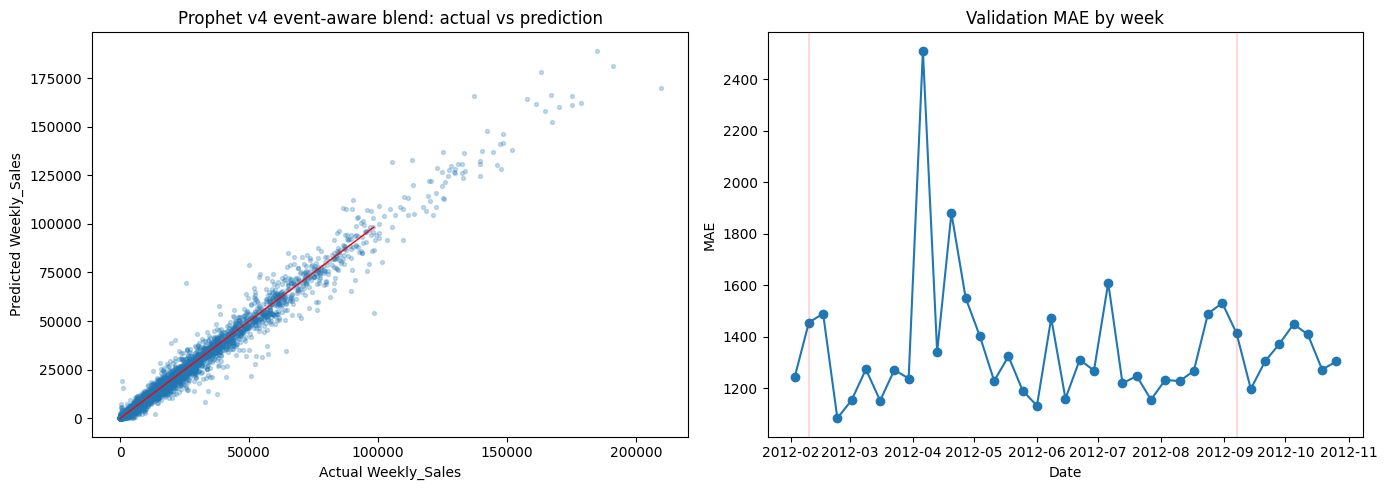

{'validation/wmae': 1367.44697173274,
 'validation/mae': 1353.8686597451197,
 'validation/raw_prophet_wmae': 1534.8593824926588,
 'validation/seasonal_naive_wmae': 1604.2696976819943,
 'validation/improvement_vs_seasonal_naive_pct': 14.762027001534655,
 'validation/improvement_vs_raw_prophet_pct': 10.907345172431105,
 'fit/series_total': 3331,
 'fit/series_fit_ok': 3259,
 'fit/series_fallback': 72,
 'fit/elapsed_minutes': 8.957848004500072}

In [46]:
run = wandb.init(
    entity=CONFIG["wandb_entity"],
    project=CONFIG["wandb_project"],
    group=CONFIG["wandb_group"],
    name=CONFIG["run_name"],
    job_type="experiment_train",
    tags=["prophet", "classical-statistical", "experiment", "seasonal-naive-blend", "event-aware-holidays", "holiday-windows", "all-series", "wmae"],
    config={**CONFIG, **split_summary},
    save_code=True,
)

val_pred_path = OUTPUT_DIR / "prophet_v4_validation_predictions.csv"
series_info_path = OUTPUT_DIR / "prophet_v4_series_info.csv"
metrics_path = OUTPUT_DIR / "prophet_v4_metrics.json"
config_path = OUTPUT_DIR / "prophet_v4_config.json"

val_pred_df.to_csv(val_pred_path, index=False)
series_info_df.to_csv(series_info_path, index=False)
metrics_path.write_text(json.dumps(metrics, indent=2))
config_path.write_text(json.dumps({**CONFIG, **split_summary}, indent=2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = val_pred_df.sample(min(8000, len(val_pred_df)), random_state=SEED)
axes[0].scatter(sample["Weekly_Sales"], sample["Prediction"], s=8, alpha=0.25)
max_axis = np.nanpercentile(sample[["Weekly_Sales", "Prediction"]].to_numpy(), 99)
axes[0].plot([0, max_axis], [0, max_axis], color="red", linewidth=1)
axes[0].set_title("Prophet v4 event-aware blend: actual vs prediction")
axes[0].set_xlabel("Actual Weekly_Sales")
axes[0].set_ylabel("Predicted Weekly_Sales")

weekly_errors = (
    val_pred_df.groupby("Date", as_index=False)
    .agg(Weekly_MAE=("AbsError", "mean"), IsHoliday=("IsHoliday", "max"))
)
axes[1].plot(weekly_errors["Date"], weekly_errors["Weekly_MAE"], marker="o")
for date in weekly_errors.loc[weekly_errors["IsHoliday"], "Date"]:
    axes[1].axvline(date, color="red", alpha=0.15)
axes[1].set_title("Validation MAE by week")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("MAE")
plt.tight_layout()
plot_path = OUTPUT_DIR / "prophet_v4_validation_diagnostics.png"
fig.savefig(plot_path, dpi=160)
plt.show()

artifact = wandb.Artifact(
    CONFIG["artifact_name"],
    type="model-evaluation",
    description="Prophet v4 event-aware holiday-window blend validation outputs.",
    metadata={**CONFIG, **metrics, **split_summary},
)
for artifact_path in [val_pred_path, series_info_path, metrics_path, config_path, plot_path]:
    artifact.add_file(str(artifact_path))
run.log_artifact(artifact, aliases=["v4", "validation", "latest"])

wandb.log({
    **metrics,
    "validation/prediction_table": wandb.Table(dataframe=val_pred_df.sample(min(20000, len(val_pred_df)), random_state=SEED)),
    "validation/series_info": wandb.Table(dataframe=series_info_df),
    "validation/weekly_errors": wandb.Table(dataframe=weekly_errors),
    "validation/diagnostic_plot": wandb.Image(str(plot_path)),
})
for key, value in metrics.items():
    run.summary[key] = value
run.summary["validation_predictions_path"] = str(val_pred_path)
run.summary["seasonal_naive_wmae"] = float(seasonal_naive_wmae)
run.summary["blend_wmae"] = float(blend_wmae)
run.summary["raw_prophet_wmae"] = float(raw_prophet_wmae)

metrics

## End run

This experiment creates validation evidence only. No Kaggle submission is generated here.

In [47]:
print("Experiment complete. W&B contains event-aware holiday configuration and blend comparison metrics.")

Experiment complete. W&B contains event-aware holiday configuration and blend comparison metrics.


In [48]:
wandb.finish()


fit/elapsed_minutes,▁
fit/series_fallback,▁
fit/series_fit_ok,▁
fit/series_total,▁
validation/improvement_vs_raw_prophet_pct,▁
validation/improvement_vs_seasonal_naive_pct,▁
validation/mae,▁
validation/raw_prophet_wmae,▁
validation/seasonal_naive_wmae,▁
validation/wmae,▁
blend_wmae,1367.44697
